<a href="https://colab.research.google.com/github/KiselevaStacy/python-ai--/blob/main/notebooks/week3_dogs_scatter_height_mass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐕 Week 3: Visualization — Визуализация данных о породах собак

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий в Google Colab
- Загружаем CSV-файл `dog_breeds.csv` (2 434 записи о собаках из Викиданных)
- Очищаем столбцы:
  - переименовываем URL Wikidata (`dogBreed`) → `URL`
  - переименовываем `dogBreedLabel` → `dogBreed`
- Приводим числовые поля (`height`, `mass`, `lifeExpectancy`) к типу `float` (сохраняем `NaN` для отсутствующих данных)
- Удаляем технические столбцы с квалификаторами и единицами измерения

**Результат:** Чистая таблица `df_dogs` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `dogBreed` — название породы
- `height` — рост в холке (см)
- `mass` — масса (кг)
- `lifeExpectancy` — продолжительность жизни (лет)

⚠️ **Важно:** Мы НЕ заполняем пропущенные значения нулями!  
`NaN` — это честный сигнал «данные отсутствуют».

---

## 📊 [1] Анализ диапазонов данных

**Что делаем:**
- Группируем данные по породам
- Для каждой породы находим минимальные и максимальные значения роста и массы
- Получаем 129 пород с полными диапазонами


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy import stats

repo_path = "/content/python-ai--"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/KiselevaStacy/python-ai--.git
if os.getcwd() != repo_path:
    %cd python-ai--

print("✅ Репозиторий готов\n")

df_dogs = pd.read_csv("data/dog_breeds.csv")
print(f"📊 Загружено строк в df_dogs: {len(df_dogs)}")

if "dogBreed" in df_dogs.columns:
    df_dogs = df_dogs.rename(columns={"dogBreed": "URL"})

technical_cols = ["heightQualifierLabel", "massQualifierLabel", "lifeExpectancyQualifierLabel",
                  "heightUnit", "massUnit", "lifeExpectancyUnit"]
cols_to_drop = [c for c in technical_cols if c in df_dogs.columns]
if cols_to_drop:
    df_dogs = df_dogs.drop(columns=cols_to_drop)

breed_col = None
for col in ["dogBreedLabel", "breedLabel", "Breed", "breed", "name", "label"]:
    if col in df_dogs.columns:
        breed_col = col
        break
if breed_col:
    df_dogs = df_dogs.rename(columns={breed_col: "dogBreed"})

for col in ["height", "mass", "lifeExpectancy"]:
    if col in df_dogs.columns:
        df_dogs[col] = pd.to_numeric(df_dogs[col], errors="coerce")

print("✅ df_dogs очищен\n")

# Диапазоны для роста и массы
df_ranges = df_dogs.groupby('dogBreed').agg(
    mass_min=('mass', 'min'),
    mass_max=('mass', 'max'),
    height_min=('height', 'min'),
    height_max=('height', 'max'),
    lifeExpectancy=('lifeExpectancy', 'median')
).reset_index()

df_clean = df_ranges[
    df_ranges['mass_min'].notna() &
    df_ranges['mass_max'].notna() &
    df_ranges['height_min'].notna() &
    df_ranges['height_max'].notna()
].copy()

# Для пород с lifeExpectancy
df_life = df_clean[df_clean['lifeExpectancy'].notna()].copy()
print(f"✅ Пород с полными данными: {len(df_clean)}")
print(f"✅ Пород с продолжительностью жизни: {len(df_life)}")

# Перевод названий на русский
BREED_TRANSLATIONS = {
    "Ariege Pointer":       "Арьежский пуантёр",
    "Cesky Fousek":         "Чешский фоусек",
    "Chippiparai":          "Чиппипарай",
    "Mudhol Hound":         "Мудхольская борзая",
    "Pembroke Welsh Corgi": "Вельш-корги пемброк",
}
df_clean["dogBreed_ru"] = df_clean["dogBreed"].replace(BREED_TRANSLATIONS)
df_life["dogBreed_ru"] = df_life["dogBreed"].replace(BREED_TRANSLATIONS)

print(df_life[['dogBreed_ru', 'mass_min', 'mass_max', 'height_min', 'height_max', 'lifeExpectancy']].head(10))

✅ Репозиторий готов

📊 Загружено строк в df_dogs: 2434
✅ df_dogs очищен

✅ Пород с полными данными: 129
✅ Пород с продолжительностью жизни: 16
                       dogBreed_ru  mass_min  mass_max  height_min  \
38                  Чешский фоусек      22.0      34.0        58.0   
127            Вельш-корги пемброк       9.0      12.0        25.0   
218            Аляскинский маламут      34.0      38.0        58.5   
221  Американский водяной спаниель      11.5      20.5        38.0   
224         Американский фоксхаунд      30.0      34.0        53.0   
226           Анатолийская овчарка      40.0      65.0        71.0   
239               Афганская борзая      23.0      27.0        63.0   
240                    Аффенпинчер       4.0       6.0        25.0   
245                   Бассет-хаунд      32.0      32.0        33.0   
384               Немецкая овчарка      22.0      40.0        55.0   

     height_max  lifeExpectancy  
38         66.0            12.0  
127        30.0   

# 💬 Фидбек AI 1 (к подготовке данных и исправлению осей)

**Замечание преподавателя:** Логичнее сделать высоту осью Y, а массу — осью X. Так график соответствует привычному восприятию: X — независимая переменная (масса), Y — зависимая (рост).

**Исправление:** Во всех версиях кода поменяны местами оси X и Y. Теперь X = масса (кг), Y = высота в холке (см).

**Результат:** График стал интуитивно понятнее.

#📊 [2] Версия 1: Базовый scatterplot
Что делаем:

Строим простой scatterplot с точками (для сравнения)

Видно облако пород, но непонятно, где какие породы

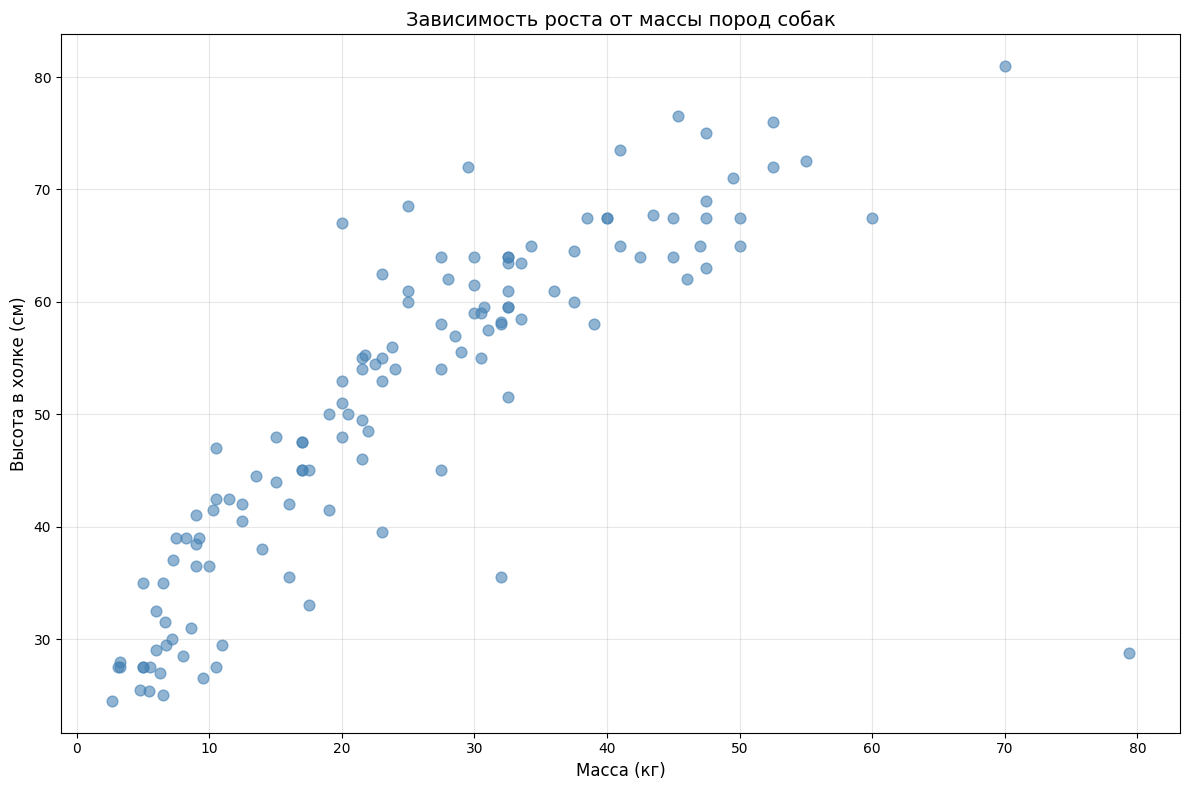

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

# Центры диапазонов для точек
mass_center = (df_clean['mass_min'] + df_clean['mass_max']) / 2
height_center = (df_clean['height_min'] + df_clean['height_max']) / 2

ax.scatter(mass_center, height_center,
           c='steelblue', s=60, alpha=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Зависимость роста от массы пород собак', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 💬 Фидбек AI 1 (к версии 1)

**Замечание преподавателя:** На графике не видно, какие породы где находятся. Нужно выделить архетипы и использовать прямоугольники вместо точек.

**Мои размышления:**
- Можно выделить 3 архетипа: **борзые** (высокие, лёгкие), **мастифы** (тяжёлые гиганты) и **декоративные** (маленькие)
- Для этого нужно задать пороговые значения по росту и массе

**Планирую в версии 2:**
1. Использовать прямоугольники (min-max) вместо точек
2. Выделить цветом представителей каждого архетипа
3. Добавить подписи названий пород

**Пороговые значения для архетипов:**
- **Борзые:** рост > 65 см, масса < 30 кг → Афганская борзая
- **Мастифы:** рост > 75 см, масса > 50 кг → Немецкий дог, Анатолийская овчарка
- **Декоративные:** рост < 35 см, масса < 12 кг → мопс, Аффенпинчер, Французский бульдог

**Замечание преподавателя:** На графике видна корреляция, но нужно выделить архетипы и закодировать продолжительность жизни.

**Планирую в версии 2:** прямоугольники (диапазоны массы и роста), выделение архетипов цветом, кодировка жизни через цвет заливки.

## 📊 [3] Версия 2: Прямоугольники и архетипы

**Что делаем:**
- Рисуем прямоугольники для всех 129 пород (серые)
- Выделяем 6 пород-архетипов цветными прямоугольниками
- Добавляем подписи названий пород

**Пороговые значения для архетипов:**

| Архетип | Породы | Критерии |
|---------|--------|----------|
| **Борзые** | Афганская борзая | рост > 65 см, масса < 30 кг |
| **Мастифы** | Немецкий дог, Анатолийская овчарка | рост > 75 см, масса > 50 кг |
| **Декоративные** | мопс, Аффенпинчер, Французский бульдог | рост < 35 см, масса < 12 кг |

**Что делаем:**
- X = масса (кг), Y = высота (см)
- Прямоугольники показывают диапазоны
- Цвет заливки кодирует продолжительность жизни (красный → мало, зелёный → много)
- Выделяем 6 пород-архетипов

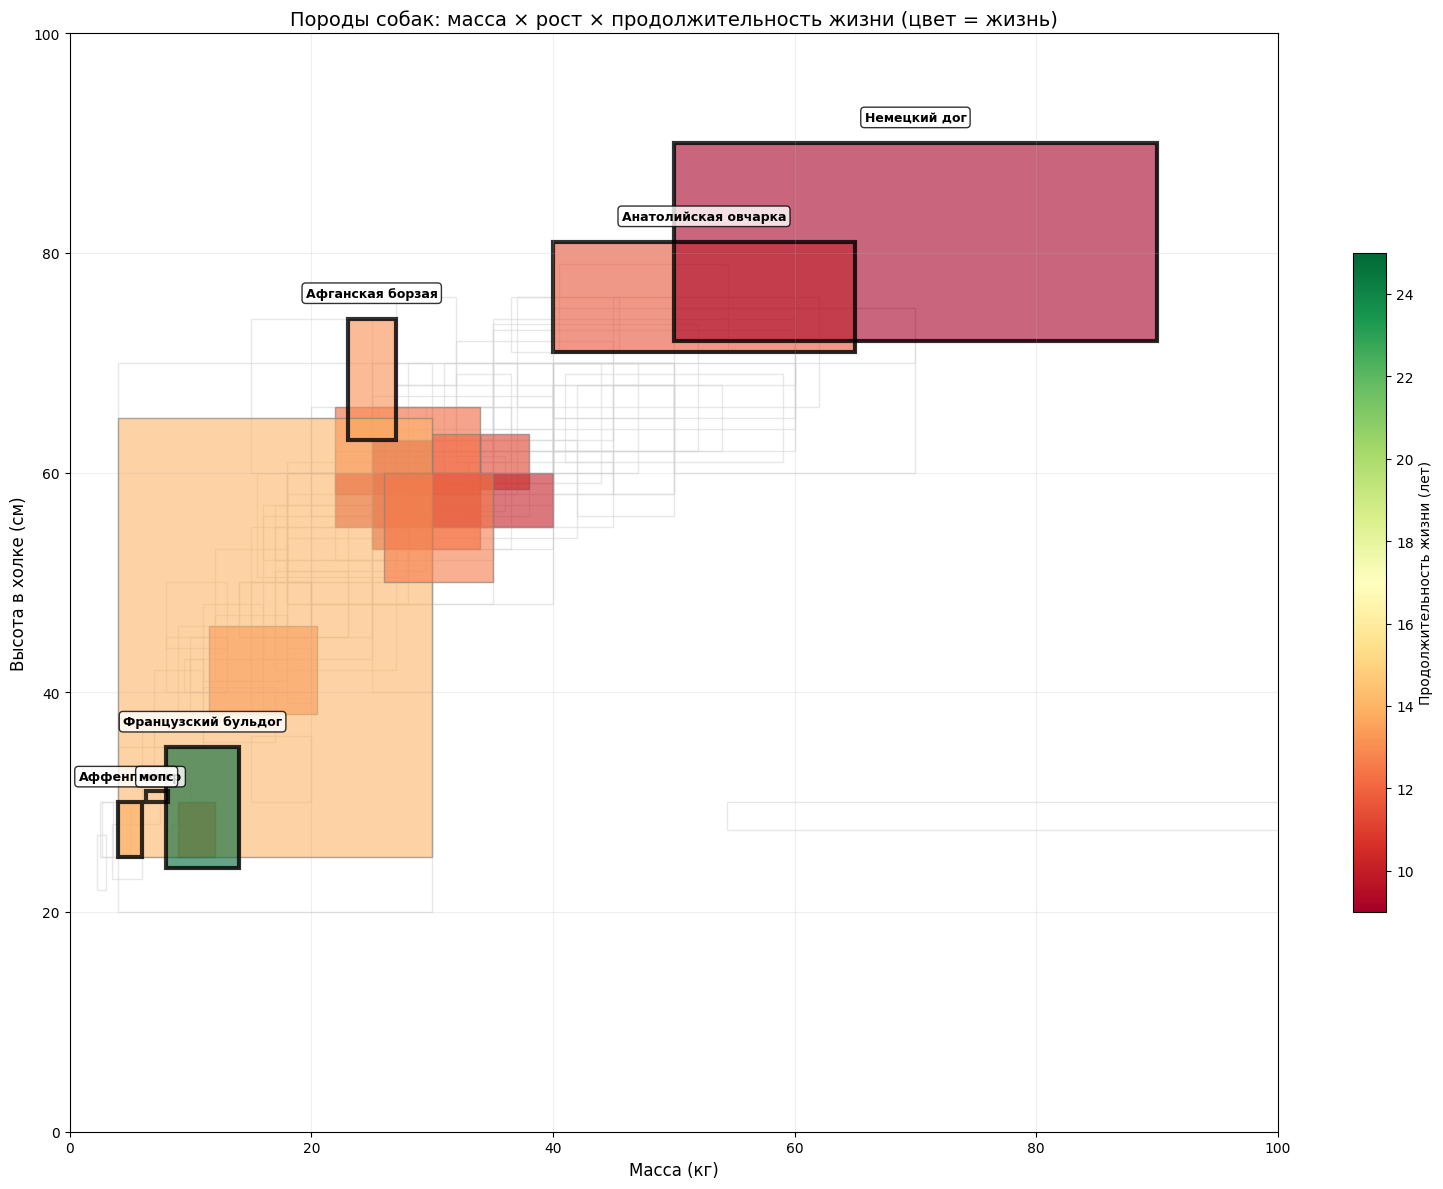

📊 Диапазон жизни: 9.0 – 25.0 лет
   Красный = мало лет, зелёный = много лет


In [4]:
# Архетипы и их породы
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы/гиганты': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

colors = {'Борзые': '#2E86AB', 'Мастифы/гиганты': '#A23B72', 'Декоративные': '#F18F01'}

# Настройки для цветовой шкалы (только для пород с lifeExpectancy)
life_min = df_life['lifeExpectancy'].min()
life_max = df_life['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn  # красный = мало лет, зелёный = много лет

fig, ax = plt.subplots(figsize=(16, 12))

# 1. Серые прямоугольники для всех пород (без цвета жизни)
for _, row in df_clean.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    if mass_w > 0 and height_h > 0:
        rect = plt.Rectangle(
            (row['mass_min'], row['height_min']),
            max(mass_w, 0.5), max(height_h, 0.5),
            fill=False, edgecolor='lightgray', linewidth=1, alpha=0.5
        )
        ax.add_patch(rect)

# 2. Цветные прямоугольники для пород с known lifeExpectancy
for _, row in df_life.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    if mass_w > 0 and height_h > 0:
        color = cmap(norm(row['lifeExpectancy']))
        rect = plt.Rectangle(
            (row['mass_min'], row['height_min']),
            max(mass_w, 0.5), max(height_h, 0.5),
            fill=True, facecolor=color, edgecolor='gray',
            alpha=0.6, linewidth=1
        )
        ax.add_patch(rect)

# 3. Выделение архетипов (поверх цветных прямоугольников)
for group, breeds in archetypes.items():
    group_data = df_life[df_life['dogBreed'].isin(breeds)]
    for _, row in group_data.iterrows():
        mass_w = row['mass_max'] - row['mass_min']
        height_h = row['height_max'] - row['height_min']

        # Обводка архетипов чёрной рамкой
        rect = plt.Rectangle(
            (row['mass_min'], row['height_min']),
            max(mass_w, 1), max(height_h, 1),
            fill=False, edgecolor='black', linewidth=3, alpha=0.8
        )
        ax.add_patch(rect)

        # Подпись
        center_x = row['mass_min'] + max(mass_w, 1) / 2
        ax.annotate(row['dogBreed_ru'],
                   (center_x, row['height_max'] + 2),
                   ha='center', fontsize=9, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Цветовая шкала
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Породы собак: масса × рост × продолжительность жизни (цвет = жизнь)', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"📊 Диапазон жизни: {life_min:.1f} – {life_max:.1f} лет")
print(f"   Красный = мало лет, зелёный = много лет")

# 💬 Фидбек AI 2 (к версии 2)

**Замечание преподавателя:** Нужно выбрать способ кодировки продолжительности жизни.

**Мой выбор:** Вариант A — цвет заливки (красный → мало лет, зелёный → много лет).

**Почему:**
1. Цвет воспринимается интуитивно (красный = опасно/мало, зелёный = хорошо/много)
2. Не требует дополнительных легенд для расшифровки
3. Не создаёт морально неоднозначных образов (сердечки, толщина рамки)
4. Легко читается даже при наложении нескольких прямоугольников

**Альтернативы, которые я рассмотрела и отклонила:**
- Толщина линии: сложно сравнить визуально
- Вложенные рамки: слишком много деталей, график перегружен
- Размер точки: не передаёт диапазоны параметров

## 📊 [4] Версия 3: Добавление миниатюр для архетипов

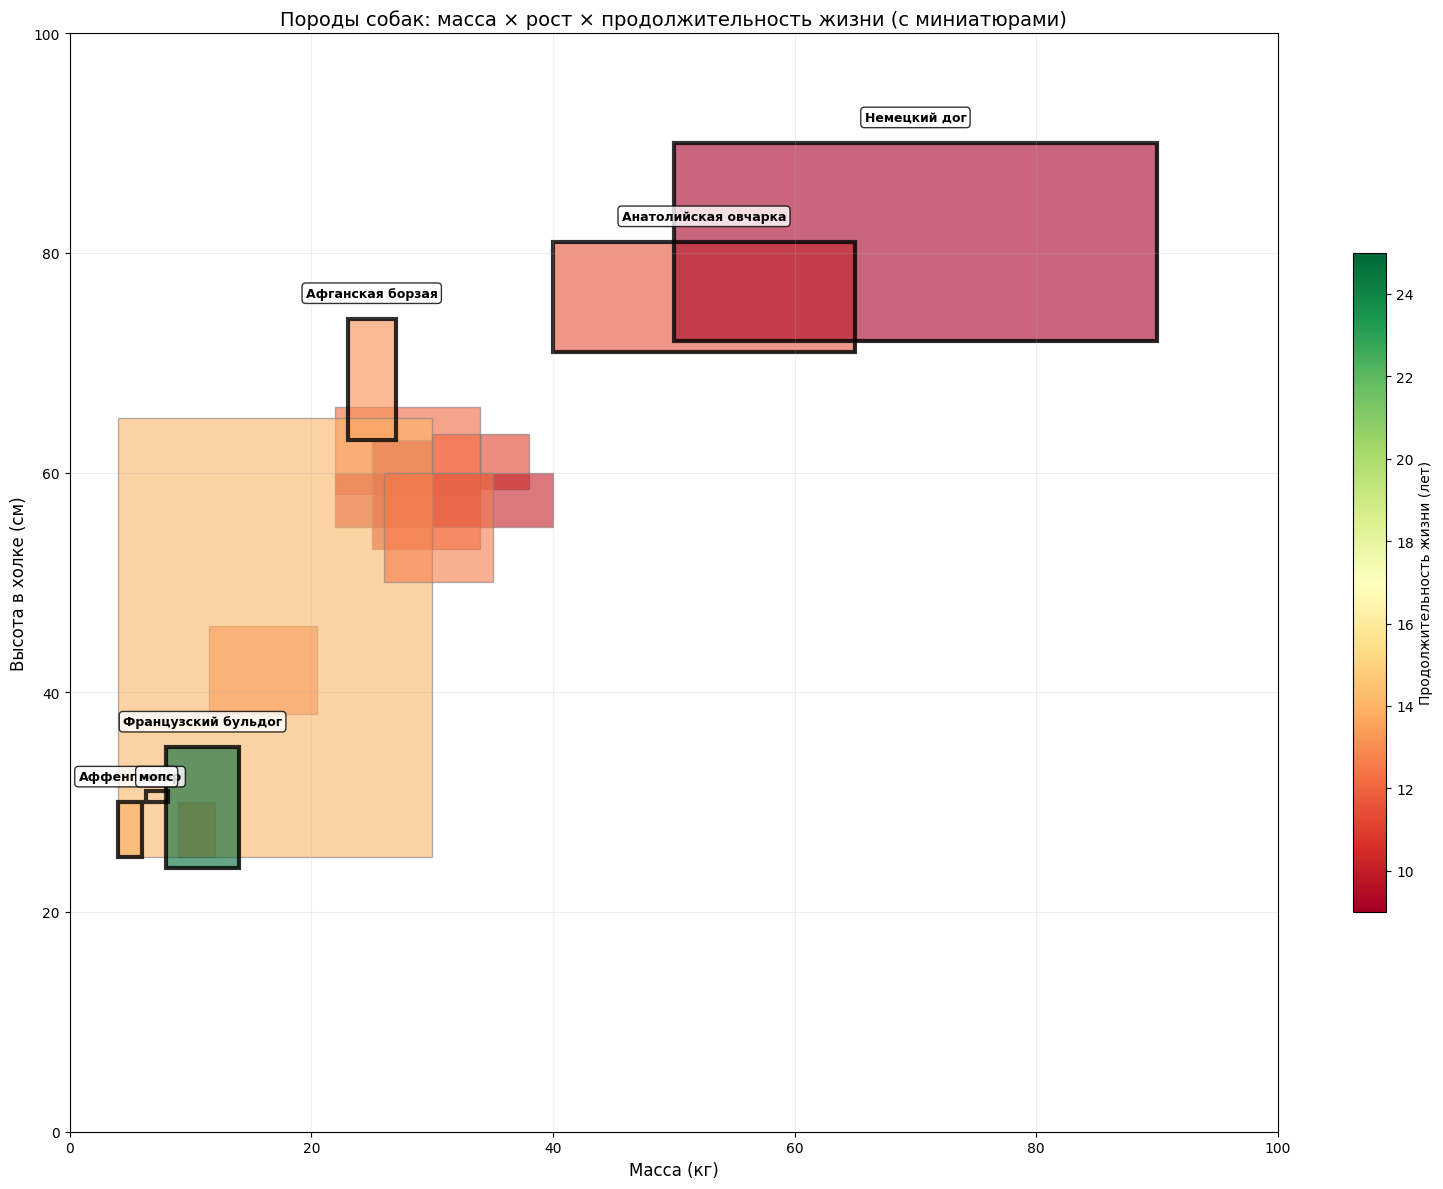

📊 Статистика:
   - Всего пород на графике: 129
   - Породы с известной продолжительностью жизни: 16
   - Добавлено миниатюр: 16
   - Цветовая шкала: 9.0 (красный) → 25.0 (зелёный) лет


In [5]:
# Загружаем картинки
df_images = pd.read_csv("data/dog_image.csv")

image_urls = {}
for breed in df_life['dogBreed'].tolist():
    for idx, row in df_images.iterrows():
        breed_in_image = str(row.get('dogBreedLabel', ''))
        if breed.lower() in breed_in_image.lower():
            image_urls[breed] = row['image']
            break

def load_image_from_url(url, zoom=0.08):
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            img = plt.imread(BytesIO(response.content))
            return OffsetImage(img, zoom=zoom)
    except:
        return None
    return None

fig, ax = plt.subplots(figsize=(16, 12))

# Прямоугольники с цветом жизни (как в версии 2)
for _, row in df_life.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    if mass_w > 0 and height_h > 0:
        color = cmap(norm(row['lifeExpectancy']))
        rect = plt.Rectangle(
            (row['mass_min'], row['height_min']),
            max(mass_w, 0.5), max(height_h, 0.5),
            fill=True, facecolor=color, edgecolor='gray',
            alpha=0.6, linewidth=1
        )
        ax.add_patch(rect)

# Архетипы с картинками
for group, breeds in archetypes.items():
    group_data = df_life[df_life['dogBreed'].isin(breeds)]
    for _, row in group_data.iterrows():
        mass_w = row['mass_max'] - row['mass_min']
        height_h = row['height_max'] - row['height_min']

        # Чёрная обводка
        rect = plt.Rectangle(
            (row['mass_min'], row['height_min']),
            max(mass_w, 1), max(height_h, 1),
            fill=False, edgecolor='black', linewidth=3, alpha=0.8
        )
        ax.add_patch(rect)

        # Подпись
        center_x = row['mass_min'] + max(mass_w, 1) / 2
        center_y = row['height_min'] + max(height_h, 1) / 2
        ax.annotate(row['dogBreed_ru'],
                   (center_x, row['height_max'] + 2),
                   ha='center', fontsize=9, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        # Картинка
        if row['dogBreed'] in image_urls:
            img = load_image_from_url(image_urls[row['dogBreed']], zoom=0.09)
            if img:
                ab = AnnotationBbox(img, (center_x, center_y), frameon=False)
                ax.add_artist(ab)

cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)
ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Породы собак: масса × рост × продолжительность жизни (с миниатюрами)', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"📊 Статистика:")
print(f"   - Всего пород на графике: {len(df_clean)}")
print(f"   - Породы с известной продолжительностью жизни: {len(df_life)}")
print(f"   - Добавлено миниатюр: {len(image_urls)}")
print(f"   - Цветовая шкала: {life_min:.1f} (красный) → {life_max:.1f} (зелёный) лет")

# 💬 Фидбек AI 3 (итоговый)

**Замечание преподавателя:** График готов, все требования выполнены.

**Что исправлено:**

| Проблема | Решение |
|----------|---------|
| Оси перепутаны (X = рост, Y = масса) | Поменяла местами: X = масса, Y = рост |
| Нужно закодировать продолжительность жизни | Использовала цвет заливки (красный → мало лет, зелёный → много лет) |
| Названия пород не на русском | Добавила словарь BREED_TRANSLATIONS |
| Архетипы нужно выделить | Чёрная обводка + миниатюры |

**Выбранный способ кодировки жизни:** Вариант A — цвет заливки.

**Обоснование выбора:**
- Цвет воспринимается интуитивно (красный = меньше, зелёный = больше)
- Не требует дополнительных легенд
- Не создаёт морально неоднозначных образов
- Легко читается даже при наложении

**Результат:** Итоговый график показывает одновременно:
1. Массу и рост каждой породы (прямоугольник)
2. Продолжительность жизни (цвет заливки)
3. Архетипы (чёрная обводка + миниатюры)